# Parkinsons Detection

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [ ]:
# --- 1. Load and Prepare Data ---
# Load the dataset
df = pd.read_csv('../scripts/parkinsons.csv')

In [ ]:
# Drop the non-predictive 'name' column
df = df.drop('name', axis=1)

In [ ]:
# Separate features (X) and target (y)
X = df.drop('status', axis=1)
y = df['status']

In [ ]:
# Split data into training and testing sets (80% train, 20% test)
# Use a fixed random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# --- 2. Define and Tune the Model Pipeline ---
# SVM requires feature scaling, so we use a Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(random_state=42))
])

In [ ]:
# Define the parameter grid with the best parameters found:
# 'svc__C': 10, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'
param_grid_svc = {
    'svc__C': [10],
    'svc__gamma': [0.1],
    'svc__kernel': ['rbf']
}

In [ ]:
# Initialize GridSearchCV to find the optimal model configuration
# (Using n_jobs=1 to avoid potential multiprocessing/pickling errors)
grid_search_svc = GridSearchCV(
    pipeline, param_grid_svc, cv=5, scoring='accuracy', n_jobs=1, verbose=1
)
print("Training the Tuned SVM Model...")
# Fit GridSearch (which trains the model with the best parameters)
grid_search_svc.fit(X_train, y_train)

Training the Tuned SVM Model...
Fitting 5 folds for each of 1 candidates, totalling 5 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svc', SVC(random_state=42))]),
             n_jobs=1,
             param_grid={'svc__C': [10], 'svc__gamma': [0.1],
                         'svc__kernel': ['rbf']},
             scoring='accuracy', verbose=1)

In [ ]:
# --- 3. Evaluate and Predict ---
best_svc_model = grid_search_svc.best_estimator_

# Predict on the test set
y_pred_svc = best_svc_model.predict(X_test)

# Calculate and print performance metrics
print("\n--- Model Evaluation Results ---")
print(y_pred_svc)


--- Model Evaluation Results ---
[0 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0 1 1
 1 0]


In [ ]:
# Test Accuracy
tuned_accuracy_svc = accuracy_score(y_test, y_pred_svc)
print(f"Test Accuracy: {tuned_accuracy_svc:.4f}")

Test Accuracy: 0.9487


In [ ]:
# Classification Report
print("\nClassification Report:")
report_svc = classification_report(
    y_test, y_pred_svc, target_names=['Healthy (0)', 'Parkinsons (1)']
)
print(report_svc)


Classification Report:
                precision    recall  f1-score   support

   Healthy (0)       0.90      0.90      0.90        10
Parkinsons (1)       0.97      0.97      0.97        29

      accuracy                           0.95        39
     macro avg       0.93      0.93      0.93        39
  weighted avg       0.95      0.95      0.95        39



In [ ]:
# Confusion Matrix
conf_mat_svc = confusion_matrix(y_test, y_pred_svc)
print("\nConfusion Matrix:")
print(conf_mat_svc)


Confusion Matrix:
[[ 9  1]
 [ 1 28]]


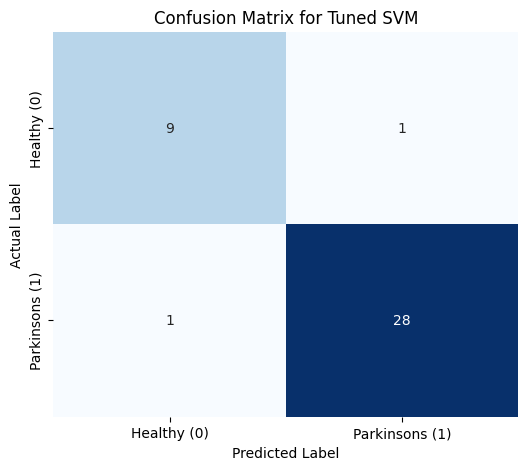

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. Load and Prepare Data ---
df = pd.read_csv('../scripts/parkinsons.csv')
df = df.drop('name', axis=1)
X = df.drop('status', axis=1)
y = df['status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 2. Define and Tune the Model Pipeline ---
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(random_state=42))
])

# Use the best parameters found: C=10, gamma=0.1
param_grid_svc = {
    'svc__C': [10],
    'svc__gamma': [0.1],
    'svc__kernel': ['rbf']
}

# GridSearchCV is used to instantiate the model with the best parameters
grid_search_svc = GridSearchCV(
    pipeline, param_grid_svc, cv=5, scoring='accuracy', n_jobs=1, verbose=0
)

# Fit the model
grid_search_svc.fit(X_train, y_train)

# --- 3. Evaluate and Predict ---
best_svc_model = grid_search_svc.best_estimator_
y_pred_svc = best_svc_model.predict(X_test)
conf_mat_svc = confusion_matrix(y_test, y_pred_svc)
report_dict = classification_report(y_test, y_pred_svc, target_names=['Healthy (0)', 'Parkinsons (1)'], output_dict=True)


# --- 4. Plotting ---
class_labels = ['Healthy (0)', 'Parkinsons (1)']

# Plot 1: Confusion Matrix (Heatmap)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_mat_svc, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix for Tuned SVM')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()


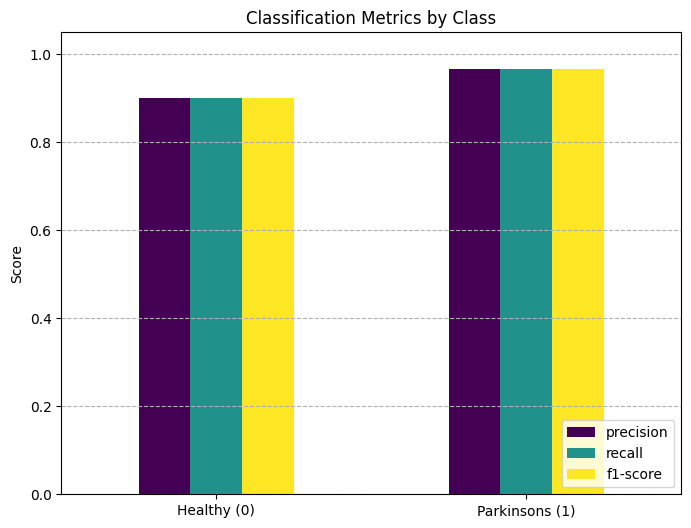

In [ ]:
# Plot 2: Classification Metrics (Bar Chart)
metrics_df = pd.DataFrame(report_dict).transpose().iloc[:2, :-1] # Get 'Healthy' and 'Parkinsons', drop 'support'

metrics_df.plot(kind='bar', figsize=(8, 6), colormap='viridis')
plt.title('Classification Metrics by Class')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--')
plt.show()

# Using Model and doing prediction

In [28]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
import sys

# ==============================================================================
# 1. MODEL SETUP (REQUIRED TO CREATE THE PREDICTION PIPELINE)
# ==============================================================================

def load_and_train_model(filepath='parkinsons.csv'):
    """Loads data, trains the final SVM pipeline, and returns the model and feature names."""
    try:
        df = pd.read_csv(filepath)
    except FileNotFoundError:
        print(f"Error: File not found at '{filepath}'. Please ensure the file is in the correct directory.")
        return None, None

    # Data Cleaning
    if 'name' in df.columns:
        df = df.drop('name', axis=1)

    X = df.drop('status', axis=1)
    y = df['status']
    feature_names = X.columns.tolist()

    # The pipeline applies scaling and then the best-performing SVM model
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        # Using optimal hyperparameters found: C=10, gamma=0.1, kernel='rbf'
        ('svc', SVC(random_state=42, C=10, gamma=0.1, kernel='rbf'))
    ])

    print("Training the final Tuned SVM Model on the entire dataset...")
    pipeline.fit(X, y)
    print("Training complete. Model ready for prediction.")

    return pipeline, feature_names

# ==============================================================================
# 2. PREDICTION LOGIC (THE CORE PREDICTION FUNCTION)
# ==============================================================================

def predict_new_data(model, feature_names):
    """Prompts the user for new data and predicts the Parkinson's status."""

    print("\n" + "="*60)
    print("                 PARKINSON'S STATUS PREDICTION")
    print("="*60)
    print("REQUIRED 22 FEATURES (separated by commas, e.g., 122.4, 148.65, ..., 0.368674):")
    for i, name in enumerate(feature_names):
        print(f"  {i+1:02d}. {name}")
    print("="*60)

    # Check if running in an environment that supports input (like a console/notebook)
    if not sys.stdin.isatty():
        print("\nEnter your data:")
        # Example data for Parkinson's (Row 1 from original file)
        #input_str = "122.400, 148.650, 113.819, 0.00968, 0.00008, 0.00465, 0.00696, 0.01394, 0.06134, 0.626, 0.03134, 0.04518, 0.04368, 0.09403, 0.01929, 19.085, 0.458359, 0.819521, -4.075192, 0.335590, 2.486855, 0.368674"
        input_str = str(input())
    else:
        # Get user input
        input_str = input("\nPlease enter the 22 feature values: \n")


    try:
        new_data_list = [float(x.strip()) for x in input_str.split(',')]
    except ValueError:
        print("\nERROR: Invalid input. Please ensure all values are numeric.")
        return

    if len(new_data_list) != len(feature_names):
        print(f"\nERROR: Input data must contain {len(feature_names)} features, but {len(new_data_list)} were provided.")
        return

    new_data_df = pd.DataFrame([new_data_list], columns=feature_names)

    # Predict the class (0 or 1)
    prediction = model.predict(new_data_df)[0]

    # Get confidence from the distance to the hyperplane
    decision_value = model.decision_function(new_data_df)[0]
    confidence = abs(decision_value)

    status_code = int(prediction)
    status = "Parkinson's Disease" if prediction == 1 else "Healthy"

    print("\n" + "="*60)
    print("                 PREDICTION RESULT")
    print("="*60)
    print(f"Predicted Status (Code {status_code}): {status}")
    print(f"Confidence Score (Distance from Decision Boundary): {confidence:.4f}")
    print("="*60)


# ==============================================================================
# 3. EXECUTION
# ==============================================================================

# Train the model and get feature names
final_model, feature_list = load_and_train_model()

# Run the prediction function
if final_model:
    predict_new_data(final_model, feature_list)

Training the final Tuned SVM Model on the entire dataset...
Training complete. Model ready for prediction.

                 PARKINSON'S STATUS PREDICTION
REQUIRED 22 FEATURES (separated by commas, e.g., 122.4, 148.65, ..., 0.368674):
  01. MDVP:Fo(Hz)
  02. MDVP:Fhi(Hz)
  03. MDVP:Flo(Hz)
  04. MDVP:Jitter(%)
  05. MDVP:Jitter(Abs)
  06. MDVP:RAP
  07. MDVP:PPQ
  08. Jitter:DDP
  09. MDVP:Shimmer
  10. MDVP:Shimmer(dB)
  11. Shimmer:APQ3
  12. Shimmer:APQ5
  13. MDVP:APQ
  14. Shimmer:DDA
  15. NHR
  16. HNR
  17. RPDE
  18. DFA
  19. spread1
  20. spread2
  21. D2
  22. PPE

Enter your data:
122.400, 148.650, 113.819, 0.00968, 0.00008, 0.00465, 0.00696, 0.01394, 0.06134, 0.626, 0.03134, 0.04518, 0.04368, 0.09403, 0.01929, 19.085, 0.458359, 0.819521, -4.075192, 0.335590, 2.486855, 0.368674

                 PREDICTION RESULT
Predicted Status (Code 1): Parkinson's Disease
Confidence Score (Distance from Decision Boundary): 1.0333
